# Machine Learning in Time Series Forecasting	

# Overview of the Section

**1. Overview of the section**

**1 What we have done so far**

**2. Overview of Applied Machine Learning in Time Series Forecasting**

**3. Dataset Preparation**

**4. Univariate-time-series-forecasting**

    1. Autoregression (AR) in Time Series Forecasting
    2. Moving Average (MA) in Time Series Forecasting
    3. Autoregressive Moving Average (ARMA) in Time Series Forecasting
    4. Autoregressive integrated moving average (ARIMA) in Time Series Forecasting
    5. Auto ARIMA in Time Series Forecasting
    6. Seasonal Autoregressive Integrated Moving-Average (SARIMA) in Time Series Forecasting
    7. Auto - SARIMA in Time Series Forecasting    


# 1-Overview of this section


# What we have done So Far

# 2. Overview of Applied Machine Learning in Time Series Forecasting



**ML Methods For Time-Series Forecasting**


# 3. Preparaing Data to Apply Forecasting

# A- First things First
**Import Libraries**



In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline

# B- Overview of the Dataset


In [3]:
df = pd.read_csv('air_pollution.csv', parse_dates=['date'])
df['pollution_yesterday'] = df['pollution_today'].shift(1)
df.set_index('date', inplace=True)
df.index = pd.date_range(start="2010-01-02 00:00:00", periods=len(df), freq="h")
df

,pollution_today,dew,temp,press,wnd_dir,wnd_spd,snow,rain,pollution_yesterday
2010-01-02 00:00:00,129.0,-16,-4.0,1020.0,SE,1.79,0,0,NaN
2010-01-02 01:00:00,148.0,-15,-4.0,1020.0,SE,2.68,0,0,129.0
2010-01-02 02:00:00,159.0,-11,-5.0,1021.0,SE,3.57,0,0,148.0
2010-01-02 03:00:00,181.0,-7,-5.0,1022.0,SE,5.36,1,0,159.0
2010-01-02 04:00:00,138.0,-7,-5.0,1022.0,SE,6.25,2,0,181.0
...,...,...,...,...,...,...,...,...,...
2014-12-31 19:00:00,8.0,-23,-2.0,1034.0,NW,231.97,0,0,10.0
2014-12-31 20:00:00,10.0,-22,-3.0,1034.0,NW,237.78,0,0,8.0
2014-12-31 21:00:00,10.0,-22,-3.0,1034.0,NW,242.70,0,0,10.0
2014-12-31 22:00:00,8.0,-22,-4.0,1034.0,NW,246.72,0,0,10.0


In [4]:
df.columns

Index(['pollution_today', 'dew', 'temp', 'press', 'wnd_dir', 'wnd_spd', 'snow',
       'rain', 'pollution_yesterday'],
      dtype='object')

In [5]:
df.drop(['dew', 'temp', 'temp',
       'press', 'wnd_spd','pollution_yesterday','snow','rain'], axis=1, inplace=True)

In [6]:
#df.set_index('date', inplace=True)

In [7]:
df

,pollution_today,wnd_dir
2010-01-02 00:00:00,129.0,SE
2010-01-02 01:00:00,148.0,SE
2010-01-02 02:00:00,159.0,SE
2010-01-02 03:00:00,181.0,SE
2010-01-02 04:00:00,138.0,SE
...,...,...
2014-12-31 19:00:00,8.0,NW
2014-12-31 20:00:00,10.0,NW
2014-12-31 21:00:00,10.0,NW
2014-12-31 22:00:00,8.0,NW


# C- Compute the Difference

In [8]:
df['pollution_today'].shift(1)

2010-01-02 00:00:00      NaN
2010-01-02 01:00:00    129.0
2010-01-02 02:00:00    148.0
2010-01-02 03:00:00    159.0
2010-01-02 04:00:00    181.0
                       ...  
2014-12-31 19:00:00     10.0
2014-12-31 20:00:00      8.0
2014-12-31 21:00:00     10.0
2014-12-31 22:00:00     10.0
2014-12-31 23:00:00      8.0
Freq: h, Name: pollution_today, Length: 43800, dtype: float64

In [9]:
df['Pollution_today First Difference']= df['pollution_today']-df['pollution_today'].shift(1)

In [10]:
df['Pollution_today Seasonal First Difference']= df['pollution_today']-df['pollution_today'].shift(24)

In [11]:
df.head(36)

,pollution_today,wnd_dir,Pollution_today First Difference,Pollution_today Seasonal First Difference
2010-01-02 00:00:00,129.0,SE,NaN,NaN
2010-01-02 01:00:00,148.0,SE,19.0,NaN
2010-01-02 02:00:00,159.0,SE,11.0,NaN
2010-01-02 03:00:00,181.0,SE,22.0,NaN
2010-01-02 04:00:00,138.0,SE,-43.0,NaN
2010-01-02 05:00:00,109.0,SE,-29.0,NaN
2010-01-02 06:00:00,105.0,SE,-4.0,NaN
2010-01-02 07:00:00,124.0,SE,19.0,NaN
2010-01-02 08:00:00,120.0,SE,-4.0,NaN
2010-01-02 09:00:00,132.0,SE,12.0,NaN


<Axes: >

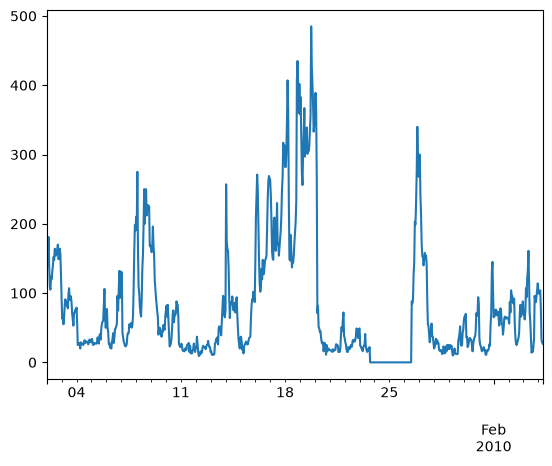

In [12]:
df['pollution_today'][:800].plot()

# Revision of Stationary Check

In [13]:
from statsmodels.tsa.stattools import adfuller

result=adfuller(df['pollution_today'])
print('ADF Statistics: %f'% result[0])
print('p value %f'% result[1])
print('critical values:')
for key, value in result[4].items():
    print('\t%s: %.3f'%(key, value))

ADF Statistics: -21.004109
p value 0.000000
critical values:
	1%: -3.430
	5%: -2.862
	10%: -2.567


In [14]:
from statsmodels.tsa.stattools import adfuller

result=adfuller(df['Pollution_today First Difference'].dropna())
print('ADF Statistics: %f'% result[0])
print('p value %f'% result[1])
print('critical values:')
for key, value in result[4].items():
    print('\t%s: %.3f'%(key, value))

ADF Statistics: -36.858517
p value 0.000000
critical values:
	1%: -3.430
	5%: -2.862
	10%: -2.567


In [15]:
from statsmodels.tsa.stattools import adfuller

result=adfuller(df['Pollution_today Seasonal First Difference'].dropna())
print('ADF Statistics: %f'% result[0])
print('p value %f'% result[1])
print('critical values:')
for key, value in result[4].items():
    print('\t%s: %.3f'%(key, value))

ADF Statistics: -31.066014
p value 0.000000
critical values:
	1%: -3.430
	5%: -2.862
	10%: -2.567


<Axes: >

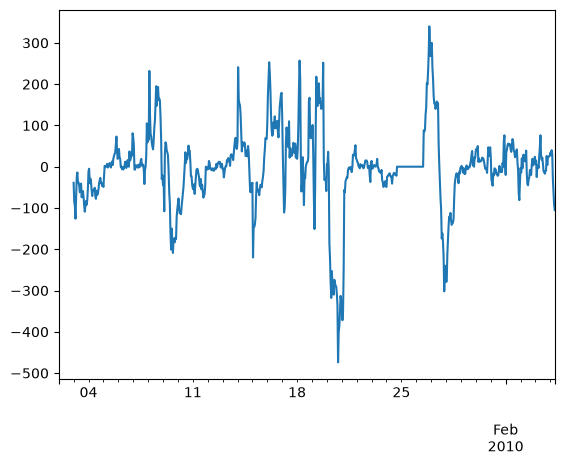

In [16]:
df['Pollution_today Seasonal First Difference'][:800].plot()

# D- Autocorrelation Check

In [17]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [18]:
import statsmodels.api as sm

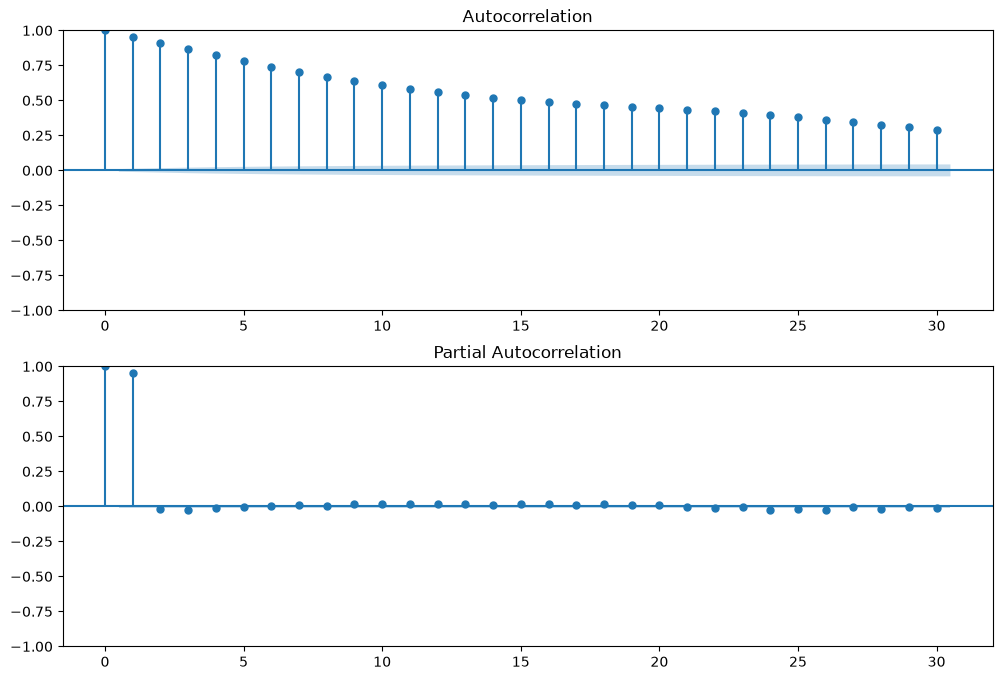

In [19]:
fig = plt.figure(figsize=(12,8))
ax1 = fig.add_subplot(211)

fig = sm.graphics.tsa.plot_acf(df['pollution_today'], lags=30, ax=ax1)

ax2=fig.add_subplot(212)
fig = sm.graphics.tsa.plot_pacf(df['pollution_today'], lags=30, ax=ax2)

In [20]:
df['Pollution_today Seasonal First Difference']

2010-01-02 00:00:00     NaN
2010-01-02 01:00:00     NaN
2010-01-02 02:00:00     NaN
2010-01-02 03:00:00     NaN
2010-01-02 04:00:00     NaN
                       ... 
2014-12-31 19:00:00   -27.0
2014-12-31 20:00:00   -16.0
2014-12-31 21:00:00   -10.0
2014-12-31 22:00:00     0.0
2014-12-31 23:00:00    -4.0
Freq: h, Name: Pollution_today Seasonal First Difference, Length: 43800, dtype: float64

In [21]:
df['Pollution_today Seasonal First Difference'].iloc[13:]

2010-01-02 13:00:00     NaN
2010-01-02 14:00:00     NaN
2010-01-02 15:00:00     NaN
2010-01-02 16:00:00     NaN
2010-01-02 17:00:00     NaN
                       ... 
2014-12-31 19:00:00   -27.0
2014-12-31 20:00:00   -16.0
2014-12-31 21:00:00   -10.0
2014-12-31 22:00:00     0.0
2014-12-31 23:00:00    -4.0
Freq: h, Name: Pollution_today Seasonal First Difference, Length: 43787, dtype: float64

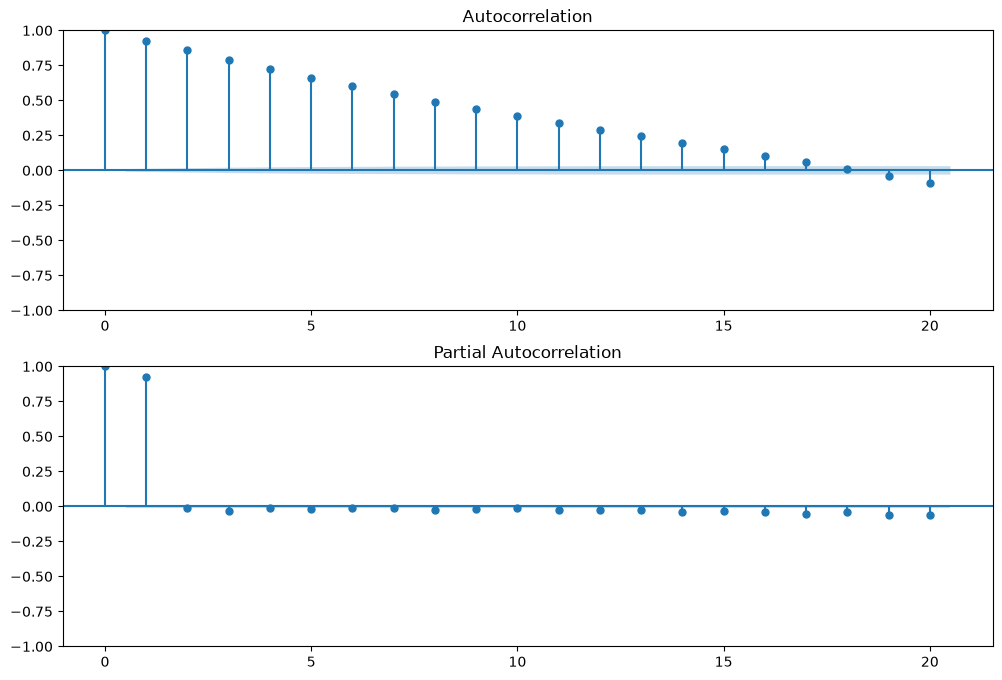

In [22]:
fig = plt.figure(figsize=(12,8))
ax1 = fig.add_subplot(211)

fig = sm.graphics.tsa.plot_acf(df['Pollution_today Seasonal First Difference'].iloc[24:], lags=20, ax=ax1)

ax2=fig.add_subplot(212)
fig = sm.graphics.tsa.plot_pacf(df['Pollution_today Seasonal First Difference'].iloc[24:], lags=20, ax=ax2)

# E- Auto-Correlation and Partial Correlation



# Data Splitting

**Prepare data before modeling**

In [23]:
resultsDict = {}
predictionsDict={}

split_date = '2010-10-01'

df_training = df.loc[df.index<=split_date]
df_test = df.loc[df.index>split_date]

print(f"{len(df_training)} days of training data\n {len(df_test)} days of testing data ")

6529 days of training data
 37271 days of testing data 


In [24]:
df_An = df[['pollution_today']]

In [25]:
df_An = df_An.resample('D').mean()

In [26]:
df_An

,pollution_today
2010-01-02,145.958333
2010-01-03,78.833333
2010-01-04,31.333333
2010-01-05,42.458333
2010-01-06,56.416667
...,...
2014-12-27,238.666667
2014-12-28,197.375000
2014-12-29,159.000000
2014-12-30,46.083333


In [27]:
resultsDict = {}
predictionsDict={}

split_date = '2010-10-01'

df_training = df_An.loc[df_An.index<=split_date]
df_test = df_An.loc[df_An.index>split_date]

print(f"{len(df_training)} days of training data\n {len(df_test)} days of testing data ")

273 days of training data
 1552 days of testing data 


In [35]:
df_test

,pollution_today
2010-10-02,35.041667
2010-10-03,10.000000
2010-10-04,24.541667
2010-10-05,77.083333
2010-10-06,268.833333
...,...
2014-12-27,238.666667
2014-12-28,197.375000
2014-12-29,159.000000
2014-12-30,46.083333


# 4- Methods for time series forecasting



# A- Autoregression (AR)

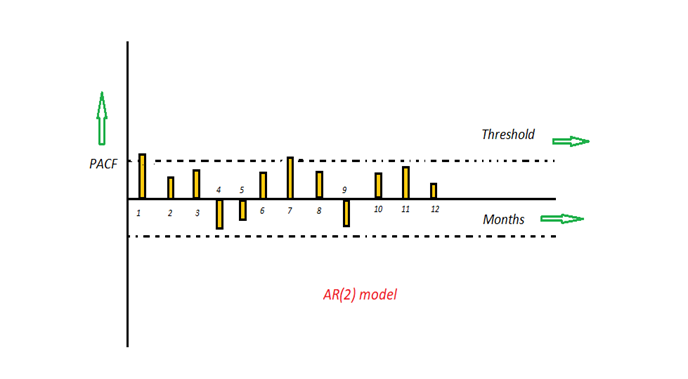

In [44]:
df_An.columns

Index(['pollution_today'], dtype='object')

In [45]:
import evaluate

In [46]:
from statsmodels.tsa.ar_model import AutoReg
from tqdm import tqdm
#from utils.metrics_utils import evaluate

In [51]:
from sklearn.metrics import mean_absolute_error as mae
import math

In [53]:
index = len(df_training)

y = list()


for t in tqdm(range(len(df_test.pollution_today))):
    temp_train = df_An[:len(df_training)+t]
    
    model = AutoReg(temp_train.pollution_today, lags=50)
    model_fit = model.fit()
    predictions = model_fit.predict(start=len(temp_train), end= len(temp_train), dynamic=False)
    
    y = y +[predictions]
    
y = pd.concat(y)

#resultsDict['AutoReg']= evaluate(df_test.pollution_today, y.values)
MSE = mae(df_test.pollution_today, y.values)
RMSE = math.sqrt(MSE)
resultsDict['AutoReg']=RMSE
predictionsDict['AutoReg']= y.values

100%|██████████| 1552/1552 [00:25<00:00, 61.29it/s]


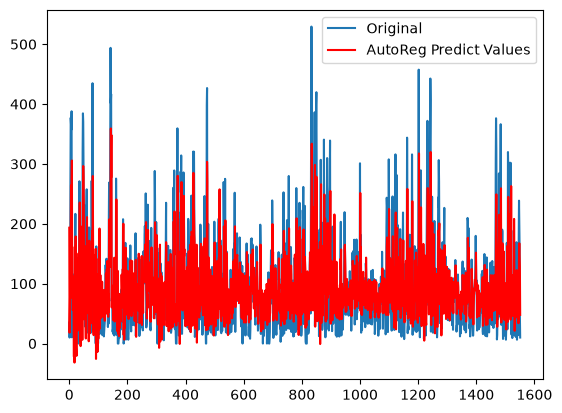

In [54]:
plt.plot(df_test.pollution_today.values, label='Original')
plt.plot(y.values, color='red', label='AutoReg Predict Values')
plt.legend()

In [55]:
model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            AutoReg Model Results                             
==============================================================================
Dep. Variable:        pollution_today   No. Observations:                 1824
Model:                    AutoReg(50)   Log Likelihood               -9832.567
Method:               Conditional MLE   S.D. of innovations             61.785
Date:                Thu, 08 Oct 2026   AIC                          19769.133
Time:                        21:16:16   BIC                          20054.145
Sample:                    02-21-2010   HQIC                         19874.419
                         - 12-30-2014                                         
=======================================================================================
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  32.3273      6.678      4.841      0.000      19.238      45.416
pollution_today.L1      0.6719      0.024     28.306      0.000       0.625       0.718
pollution_today.L2     -0.1993      0.029     -6.973      0.000      -0.255      -0.143
pollution_today.L3      0.0675      0.029      2.330      0.020       0.011       0.124
pollution_today.L4     -0.0394      0.029     -1.357      0.175      -0.096       0.017
pollution_today.L5      0.0363      0.029      1.252      0.211      -0.021       0.093
pollution_today.L6     -0.0024      0.029     -0.084      0.933      -0.059       0.054
pollution_today.L7     -0.0093      0.029     -0.321      0.748      -0.066       0.048
pollution_today.L8      0.0140      0.029      0.485      0.628      -0.043       0.071
pollution_today.L9      0.0205      0.029      0.710      0.478      -0.036       0.077
pollution_today.L10    -0.0188      0.029     -0.651      0.515      -0.075       0.038
pollution_today.L11     0.0803      0.029      2.779      0.005       0.024       0.137
pollution_today.L12    -0.0923      0.029     -3.189      0.001      -0.149      -0.036
pollution_today.L13     0.0516      0.029      1.776      0.076      -0.005       0.108
pollution_today.L14     0.0004      0.029      0.015      0.988      -0.057       0.057
pollution_today.L15     0.0139      0.029      0.480      0.631      -0.043       0.071
pollution_today.L16    -0.0173      0.029     -0.596      0.551      -0.074       0.040
pollution_today.L17     0.0234      0.029      0.805      0.421      -0.034       0.080
pollution_today.L18    -0.0036      0.029     -0.124      0.901      -0.061       0.053
pollution_today.L19    -0.0352      0.029     -1.212      0.225      -0.092       0.022
pollution_today.L20    -0.0376      0.029     -1.295      0.195      -0.095       0.019
pollution_today.L21     0.0714      0.029      2.456      0.014       0.014       0.128
pollution_today.L22    -0.0167      0.029     -0.572      0.567      -0.074       0.040
pollution_today.L23     0.0236      0.029      0.808      0.419      -0.034       0.081
pollution_today.L24    -0.0515      0.029     -1.768      0.077      -0.109       0.006
pollution_today.L25     0.0227      0.029      0.778      0.436      -0.034       0.080
pollution_today.L26    -0.0090      0.029     -0.310      0.756      -0.066       0.048
pollution_today.L27    -0.0139      0.029     -0.476      0.634      -0.071       0.043
pollution_today.L28     0.0471      0.029      1.616      0.106      -0.010       0.104
pollution_today.L29    -0.0253      0.029     -0.867      0.386      -0.082       0.032
pollution_today.L30     0.0271      0.029      0.933      0.351      -0.030       0.084
pollution_today.L31     0.0077      0.029      0.265      0.791      -0.049       0.065
pollution_today.L32    -0.0138      0.029     -0.472      0.637      -0.071       0.043
pollution_today.L33     0.0231      0.029      0.793      0.428      -0.0

# B-Moving average

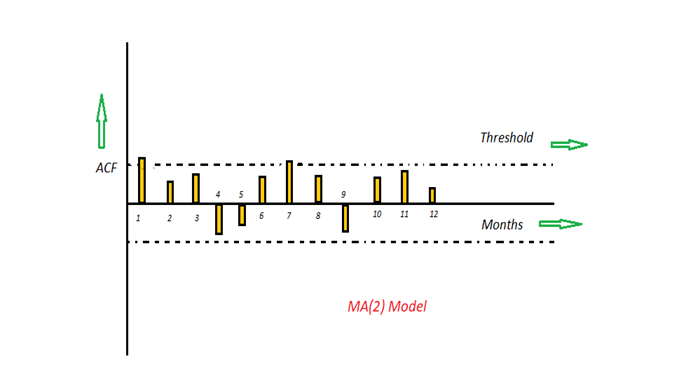

# C- ARMA





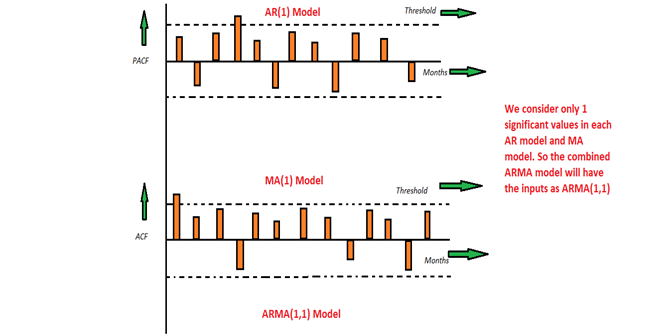




# D- Auto-Regressive Integrated Moving Average (ARIMA) Model



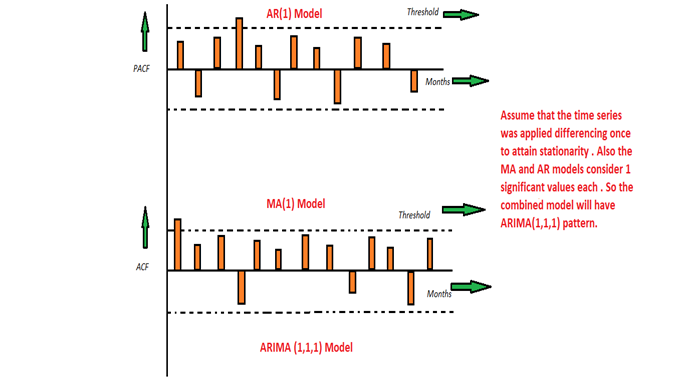


In [56]:
from statsmodels.tsa.arima.model import ARIMA

In [57]:
model=ARIMA(df_An['pollution_today'], order=(1,1,1))
model_fit=model.fit()

In [58]:
model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:        pollution_today   No. Observations:                 1825
Model:                 ARIMA(1, 1, 1)   Log Likelihood              -10165.883
Date:                Thu, 08 Oct 2026   AIC                          20337.765
Time:                        21:17:51   BIC                          20354.292
Sample:                    01-02-2010   HQIC                         20343.862
                         - 12-31-2014                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5695      0.013     43.128      0.000       0.544       0.595
ma.L1         -0.9998      0.014    -69.297      0.000      -1.028      -0.971
sigma2      4049.0677    106.529     38.009      0.000    3840.275    4257.860
===================================================================================
Ljung-Box (L1) (Q):                  14.92   Jarque-Bera (JB):               417.78
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               1.04   Skew:                             0.67
Prob(H) (two-sided):                  0.65   Kurtosis:                         4.92
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

<Axes: >

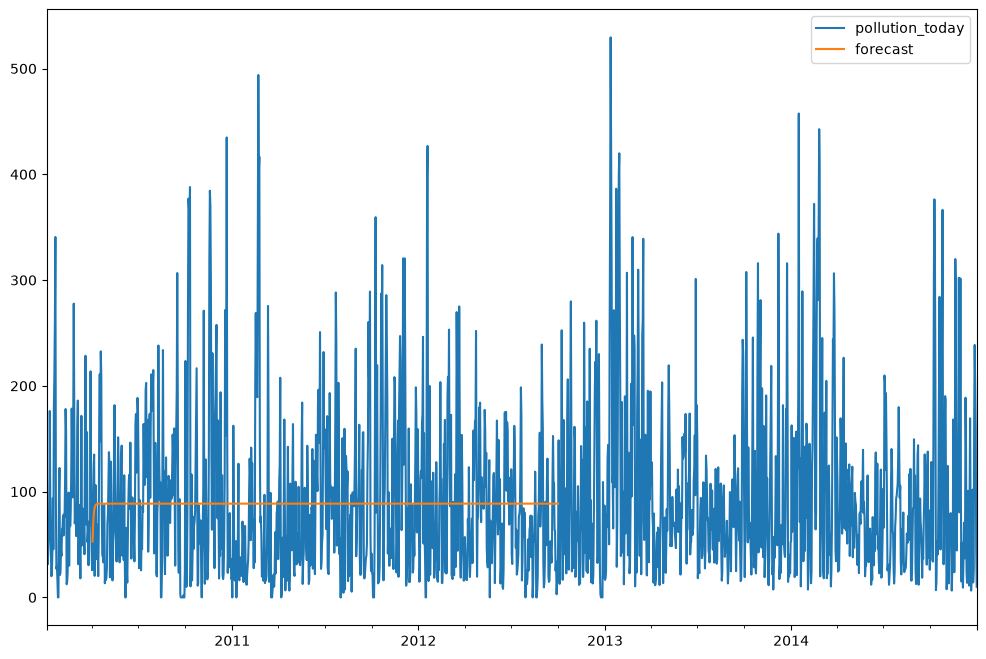

In [64]:
df_An['forecast']=model_fit.predict(start=90, end=1003, dynamic=True)

df_An[['pollution_today','forecast']].plot(figsize=(12,8))

In [65]:
df_An['forecast']

2010-01-02   NaN
2010-01-03   NaN
2010-01-04   NaN
2010-01-05   NaN
2010-01-06   NaN
              ..
2014-12-27   NaN
2014-12-28   NaN
2014-12-29   NaN
2014-12-30   NaN
2014-12-31   NaN
Freq: D, Name: forecast, Length: 1825, dtype: float64

C:\Users\ftorr\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<Axes: >

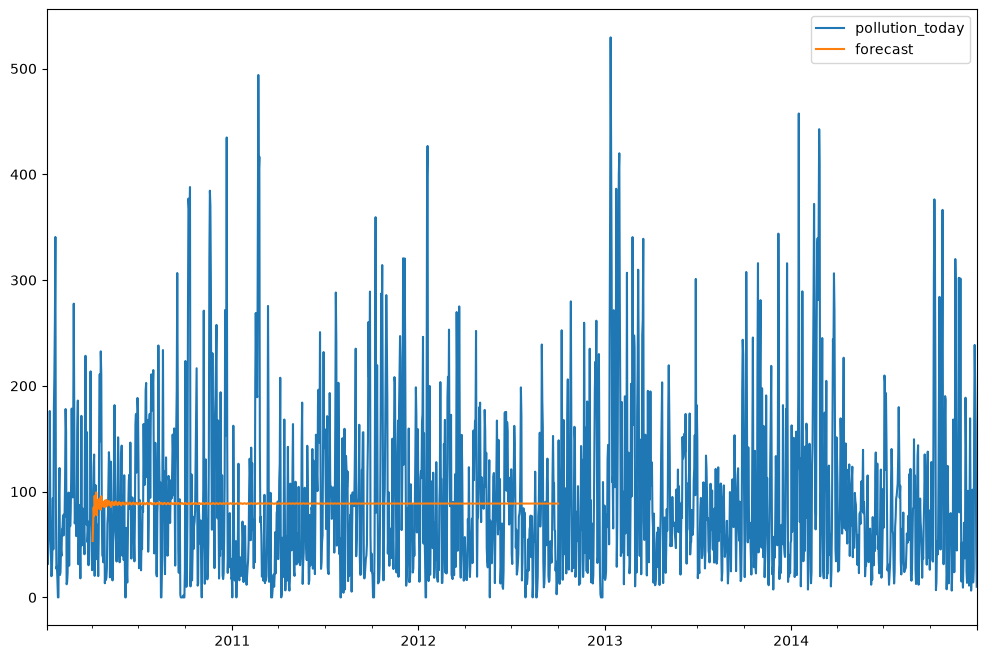

In [66]:
model=ARIMA(df_An['pollution_today'], order=(10,1,10))

model_fit=model.fit()
model_fit.summary()

df_An['forecast']=model_fit.predict(start=90, end=1003, dynamic=True)

df_An[['pollution_today','forecast']].plot(figsize=(12,8))

# E- Auto ARIMA

In [68]:
import pmdarima as pm

In [69]:
autoModel = pm.auto_arima(df_training.pollution_today, trace=True, error_action='ignore', suppress_warnings=True, seasonal=False)
autoModel.fit(df_training.pollution_today)

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.24 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=3344.838, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=2992.243, Time=0.03 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=3132.408, Time=0.03 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=2994.228, Time=0.02 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=2994.205, Time=0.04 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=2989.777, Time=0.07 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=inf, Time=0.20 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=inf, Time=0.20 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=2977.583, Time=0.03 sec
 ARIMA(4,0,0)(0,0,0)[0]             : AIC=2978.093, Time=0.07 sec
 ARIMA(4,0,1)(0,0,0)[0]             : AIC=inf, Time=0.24 sec
 ARIMA(3,0,0)(0,0,0)[0] intercept   : AIC=2934.624, Time=0.03 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=2934.134, Time=0.05 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=2943.650, T

,order,"(1, ...)"
,suppress_warnings,True
,scoring_args,{}
,seasonal_order,"(0, ...)"
,start_params,None
,method,'lbfgs'
,maxiter,50
,out_of_sample_size,0
,scoring,'mse'
,trend,None
,with_intercept,True


In [71]:
order = autoModel.order

yhat = list()


for t in tqdm(range(len(df_test.pollution_today))):
    temp_train = df_An[:len(df_training)+t]
    
    model = ARIMA(temp_train.pollution_today, order=order)
    model_fit = model.fit()
    predictions = model_fit.predict(start=len(temp_train), end= len(temp_train), dynamic=False)
    
    yhat = yhat +[predictions]
    
yhat = pd.concat(yhat)

resultsDict['AutoARIMA{0}'. format(order)]= mae(df_test.pollution_today, yhat)
predictionsDict['AutoARIMA{0}'. format(order)]= yhat.values

100%|██████████| 1552/1552 [02:45<00:00,  9.40it/s]


In [72]:
model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:        pollution_today   No. Observations:                 1824
Model:                 ARIMA(1, 0, 1)   Log Likelihood              -10136.843
Date:                Thu, 08 Oct 2026   AIC                          20281.687
Time:                        21:31:09   BIC                          20303.722
Sample:                    01-02-2010   HQIC                         20289.815
                         - 12-30-2014                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         94.0595      3.866     24.332      0.000      86.483     101.636
ar.L1          0.3747      0.029     12.984      0.000       0.318       0.431
ma.L1          0.2939      0.033      8.959      0.000       0.230       0.358
sigma2      3939.3248    101.611     38.769      0.000    3740.171    4138.478
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):               415.61
Prob(Q):                              0.97   Prob(JB):                         0.00
Heteroskedasticity (H):               1.02   Skew:                             0.69
Prob(H) (two-sided):                  0.82   Kurtosis:                         4.89
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

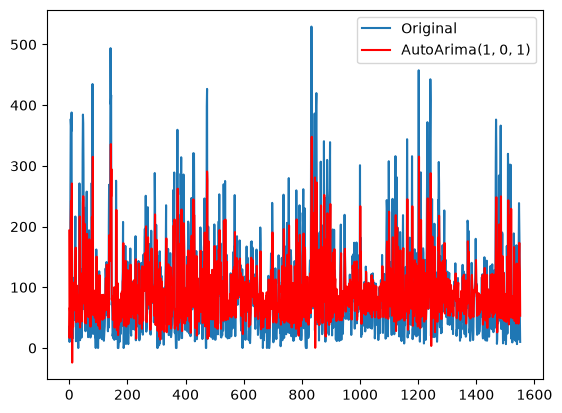

In [73]:
plt.plot(df_test.pollution_today.values, label='Original')
plt.plot(yhat.values, color='red', label='AutoArima{0}'.format(order))
plt.legend()


# SARIMA and SARIMAX


# F- Seasonal Autoregressive Integrated Moving-Average (SARIMA)


In [42]:
import statsmodels.api as sm

In [74]:
model = sm.tsa.statespace.SARIMAX(df_An['pollution_today'], order=(10,1,10), seasonal_order=(1,1,1,12))
results=model.fit()

C:\Users\ftorr\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [75]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                       SARIMAX Results                                        
==============================================================================================
Dep. Variable:                        pollution_today   No. Observations:                 1825
Model:             SARIMAX(10, 1, 10)x(1, 1, [1], 12)   Log Likelihood              -10249.593
Date:                                Thu, 08 Oct 2026   AIC                          20545.185
Time:                                        21:39:31   BIC                          20671.735
Sample:                                    01-02-2010   HQIC                         20591.884
                                         - 12-31-2014                                         
Covariance Type:                                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8301      0.183     -4.539      0.000      -1.189      -0.472
ar.L2         -0.9627      0.291     -3.312      0.001      -1.532      -0.393
ar.L3         -1.0774      0.381     -2.831      0.005      -1.823      -0.331
ar.L4         -1.3191      0.421     -3.136      0.002      -2.144      -0.495
ar.L5         -0.9572      0.400     -2.395      0.017      -1.741      -0.174
ar.L6         -0.3846      0.336     -1.144      0.253      -1.044       0.275
ar.L7         -0.3205      0.262     -1.221      0.222      -0.835       0.194
ar.L8         -0.2466      0.148     -1.665      0.096      -0.537       0.044
ar.L9         -0.1470      0.086     -1.713      0.087      -0.315       0.021
ar.L10         0.5449      0.106      5.118      0.000       0.336       0.754
ma.L1          0.4603      8.323      0.055      0.956     -15.852      16.773
ma.L2          0.3827     12.206      0.031      0.975     -23.541      24.307
ma.L3          0.3568     15.351      0.023      0.981     -29.730      30.443
ma.L4          0.4445     18.367      0.024      0.981     -35.553      36.442
ma.L5         -0.0759     22.002     -0.003      0.997     -43.199      43.047
ma.L6         -0.6092     21.447     -0.028      0.977     -42.644      41.426
ma.L7         -0.4430     16.293     -0.027      0.978     -32.377      31.491
ma.L8         -0.3263     12.666     -0.026      0.979     -25.151      24.499
ma.L9         -0.2984      9.881     -0.030      0.976     -19.664      19.067
ma.L10        -0.8914      7.481     -0.119      0.905     -15.554      13.771
ar.S.L12      -0.0658      0.043     -1.520      0.128      -0.151       0.019
ma.S.L12      -0.9990      0.170     -5.890      0.000      -1.331      -0.667
sigma2      7128.1571   5.98e+04      0.119      0.905    -1.1e+05    1.24e+05
===================================================================================
Ljung-Box (L1) (Q):                   4.94   Jarque-Bera (JB):               334.14
Prob(Q):                              0.03   Prob(JB):                         0.00
Heteroskedasticity (H):               1.07   Skew:                             0.52
Prob(H) (two-sided):                  0.41   Kurtosis:                         4.83
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 4.29e+14. Standard errors may be unstable.
"""

<Axes: >

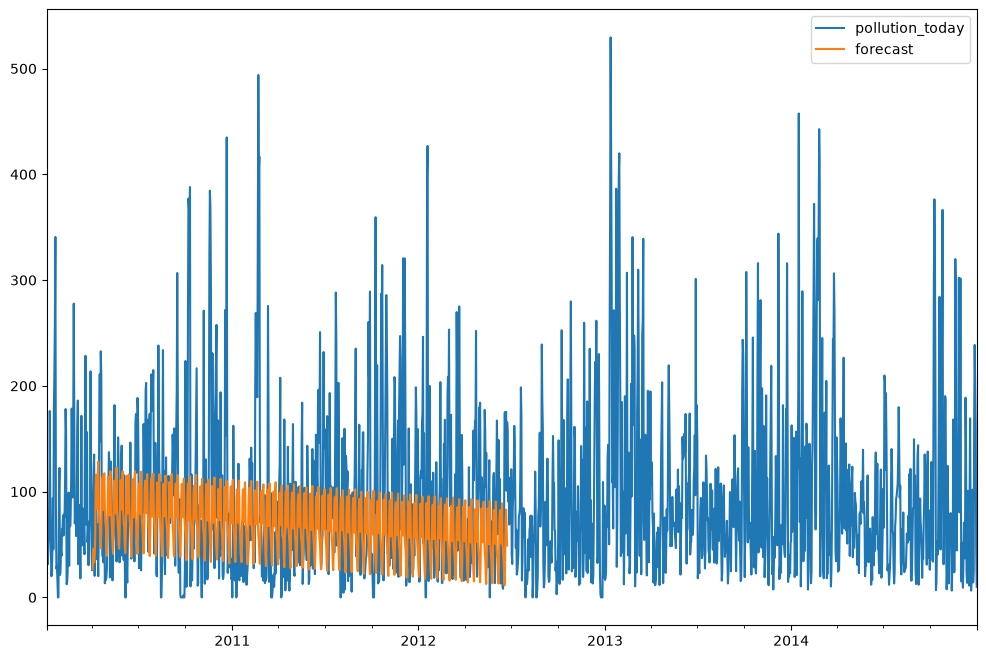

In [78]:
df_An['forecast']=results.predict(start=90,end=903,dynamic=True)
df_An[['pollution_today','forecast']].plot(figsize=(12,8))

# FUTURE DF

In [79]:
from pandas.tseries.offsets import DateOffset

In [80]:
future_dates= [df_An.index[-1]+DateOffset(months=x)for x in range(0,24)]

In [83]:
future_dates

[Timestamp('2014-12-31 00:00:00'),
 Timestamp('2015-01-31 00:00:00'),
 Timestamp('2015-02-28 00:00:00'),
 Timestamp('2015-03-31 00:00:00'),
 Timestamp('2015-04-30 00:00:00'),
 Timestamp('2015-05-31 00:00:00'),
 Timestamp('2015-06-30 00:00:00'),
 Timestamp('2015-07-31 00:00:00'),
 Timestamp('2015-08-31 00:00:00'),
 Timestamp('2015-09-30 00:00:00'),
 Timestamp('2015-10-31 00:00:00'),
 Timestamp('2015-11-30 00:00:00'),
 Timestamp('2015-12-31 00:00:00'),
 Timestamp('2016-01-31 00:00:00'),
 Timestamp('2016-02-29 00:00:00'),
 Timestamp('2016-03-31 00:00:00'),
 Timestamp('2016-04-30 00:00:00'),
 Timestamp('2016-05-31 00:00:00'),
 Timestamp('2016-06-30 00:00:00'),
 Timestamp('2016-07-31 00:00:00'),
 Timestamp('2016-08-31 00:00:00'),
 Timestamp('2016-09-30 00:00:00'),
 Timestamp('2016-10-31 00:00:00'),
 Timestamp('2016-11-30 00:00:00')]

In [84]:
future_datest_df = pd.DataFrame(index=future_dates[1:],columns=df_An.columns)

In [85]:
future_datest_df.tail(3)

,pollution_today,forecast
2016-09-30,NaN,NaN
2016-10-31,NaN,NaN
2016-11-30,NaN,NaN


In [86]:
future_df= pd.concat([df_An,future_datest_df])

C:\Users\ftorr\AppData\Local\Temp\ipykernel_5252\631889791.py:1: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  future_df= pd.concat([df_An,future_datest_df])


In [87]:
future_df

,pollution_today,forecast
2010-01-02,145.958333,NaN
2010-01-03,78.833333,NaN
2010-01-04,31.333333,NaN
2010-01-05,42.458333,NaN
2010-01-06,56.416667,NaN
...,...,...
2016-07-31,NaN,NaN
2016-08-31,NaN,NaN
2016-09-30,NaN,NaN
2016-10-31,NaN,NaN


<Axes: >

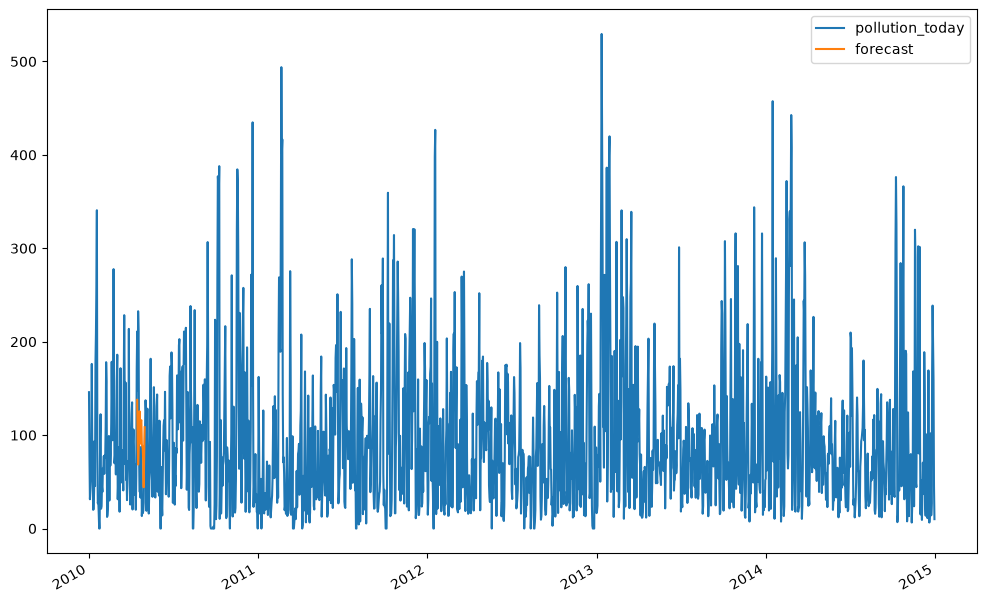

In [88]:
future_df['forecast']= results.predict(start=104, end=120, dynamic=True)

future_df[['pollution_today','forecast']].plot(figsize=(12,8))

# G -SARIMAX


# H- Auto SARIMA

In [89]:
autoModel = pm.auto_arima(df_training.pollution_today, trace=True, error_action='ignore',
                          suppress_warnings=True, seasonal=True, m=6, stepwise=True)
autoModel.fit(df_training.pollution_today)

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[6] intercept   : AIC=2936.715, Time=0.46 sec
 ARIMA(0,0,0)(0,0,0)[6] intercept   : AIC=3038.323, Time=0.01 sec
 ARIMA(1,0,0)(1,0,0)[6] intercept   : AIC=2943.907, Time=0.21 sec
 ARIMA(0,0,1)(0,0,1)[6] intercept   : AIC=2936.937, Time=0.15 sec
 ARIMA(0,0,0)(0,0,0)[6]             : AIC=3344.838, Time=0.01 sec
 ARIMA(2,0,2)(0,0,1)[6] intercept   : AIC=2935.244, Time=0.28 sec
 ARIMA(2,0,2)(0,0,0)[6] intercept   : AIC=2935.673, Time=0.07 sec
 ARIMA(2,0,2)(0,0,2)[6] intercept   : AIC=2935.901, Time=0.32 sec
 ARIMA(2,0,2)(1,0,0)[6] intercept   : AIC=2935.612, Time=0.28 sec
 ARIMA(2,0,2)(1,0,2)[6] intercept   : AIC=2933.824, Time=0.83 sec
 ARIMA(2,0,2)(2,0,2)[6] intercept   : AIC=2940.530, Time=0.81 sec
 ARIMA(2,0,2)(2,0,1)[6] intercept   : AIC=2933.131, Time=0.77 sec
 ARIMA(2,0,2)(2,0,0)[6] intercept   : AIC=2935.524, Time=0.37 sec
 ARIMA(1,0,2)(2,0,1)[6] intercept   : AIC=2933.941, Time=0.61 sec
 ARIMA(2,0,1)(2,0,1)[6] intercept

,order,"(2, ...)"
,seasonal_order,"(2, ...)"
,suppress_warnings,True
,scoring_args,{}
,start_params,None
,method,'lbfgs'
,maxiter,50
,out_of_sample_size,0
,scoring,'mse'
,trend,None
,with_intercept,True


In [90]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [91]:
order = autoModel.order
seasonalOrder = autoModel.seasonal_order

yhat = list()

for t in tqdm(range(len(df_test.pollution_today))):
    temp_train = df_An[:len(df_training)+t]
    model = SARIMAX(temp_train.pollution_today, order=order,
                    seasonal_order=seasonalOrder)
    model_fit = model.fit(disp=False)
    predictions = model_fit.predict(
        start=len(temp_train), end=len(temp_train), dynamic=False)
    yhat = yhat + [predictions]

yhat = pd.concat(yhat)
resultsDict['AutoSARIMAX {0},{1}'.format(order, seasonalOrder)] = mae(
    df_test.pollution_today, yhat.values)
predictionsDict['AutoSARIMAX {0},{1}'.format(
    order, seasonalOrder)] = yhat.values

  0%|          | 0/1552 [00:00<?, ?it/s]C:\Users\ftorr\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
  0%|          | 1/1552 [00:00<19:34,  1.32it/s]C:\Users\ftorr\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
  0%|          | 2/1552 [00:01<17:47,  1.45it/s]C:\Users\ftorr\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
  0%|          | 3/1552 [00:02<17:21,  1.49it/s]C:\Users\ftorr\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to conve

LinAlgError: LU decomposition error.

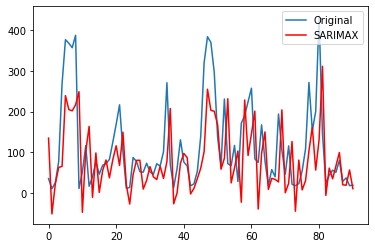

In [60]:
plt.plot(df_test.pollution_today.values, label='Original')
plt.plot(yhat.values, color='red', label='SARIMAX')
plt.legend()